# CNN Baseline (ResNet50) - ACL Classifier

Pipeline para entrenar modelos ResNet50 independientes por plano anatómico.
**Igual a ViT baseline, pero con ResNet50 como backbone en lugar de ViT.**

**Diferencias respecto a train.ipynb:**
- Usa ResNet50 pre-entrenado (19M parámetros vs 86M del ViT)
- Procesamiento más rápido (~10-15 min/plano vs 20-30 min)
- Misma configuración de preprocesado, augmentation, loss y evaluación
- Checkpoints guardados en `checkpoints/cnn_baseline_resnet50/`

## 1⃣ Imports y Configuración

In [ ]:
# Imports estándar
import os
import json
import numpy as np
import pandas as pd
from pathlib import Path
from typing import Dict, List, Tuple, Optional
import warnings
warnings.filterwarnings('ignore')

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Métricas y evaluación
from sklearn.metrics import roc_auc_score, roc_curve, f1_score

# Módulos locales

import sys
sys.path.insert(0, '../../src')

from gpu_config import device, VIT_GPU_IDS, CNN_GPU_ID
from models import CNNMultiSliceClassifier
from data_loader import OptimizedMRNetDataset, get_train_transform, get_val_test_transform
from training_utils import train_model

print(" Todos los módulos importados exitosamente")

 Todos los módulos importados exitosamente


## 2⃣ Configuración Global (Idéntica a train.ipynb)

In [17]:
# ==========================================
# RUTAS Y DIRECTORIOS
# ==========================================
DATA_PATH = Path('../../data')
CHECKPOINT_DIR = Path('../../checkpoints/cnn_baseline_resnet50')
SLICE_INDICES_DIR = Path('../data/slice_indices_final')

CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

# ==========================================
# ESTRATEGIA DE SLICES (IGUAL QUE VIT)
# ==========================================
PLANE_CONFIG = {
    'sagittal': {
        'num_slices': 5,
        'strategy': 'cnn_based',
        'pooling_mode': 'attention',
        'description': 'CNN Selector V3'
    },
    'coronal': {
        'num_slices': 10,
        'strategy': 'cnn_based',
        'pooling_mode': 'max',
        'description': 'CNN Selector Coronal'
    },
    'axial': {
        'num_slices': 10,
        'strategy': 'center_consecutive',
        'pooling_mode': 'attention',
        'description': '10 slices centrales'
    }
}

PLANES = ['sagittal', 'coronal', 'axial']

IMAGE_SIZE = 224
NUM_CLASSES = 1
BATCH_SIZE = 64
NUM_WORKERS = 8
SEED = 42
NUM_EPOCHS = 150

# ==========================================
# CONFIGURACIÓN DE AUGMENTATION POR PLANO
# ==========================================
AUGMENTATION_MODE_PER_PLANE = {
    'sagittal': 'aggressive',
    'coronal': 'moderate',
    'axial': 'aggressive'
}

# ==========================================
# CONFIGURACIÓN ESPECÍFICA POR PLANO
# ==========================================
PLANE_SPECIFIC_CONFIG = {
    'sagittal': {
        'learning_rate': 1.2e-4,
        'weight_decay': 1.7e-3,
        'dropout_input': 0.42,
        'dropout_dense': 0.32,
        'use_scheduler': False,
        'use_grad_clip': True,
        'grad_clip_norm': 1.0,
        'early_stopping_patience': 12,
        'label_smoothing': 0.17,
        'warmup_epochs': 0,
        'use_lr_plateau_scheduler': True,
        'lr_reduction_factor': 0.5,
        'lr_plateau_patience': 5,
        'status': ' CNN ResNet50 - Conservative Aug + Strong Regularization + LR Annealing'
    },
    'coronal': {
        'learning_rate': 1.0e-4,
        'weight_decay': 2.2e-3,
        'dropout_input': 0.47,
        'dropout_dense': 0.37,
        'use_scheduler': False,
        'use_grad_clip': True,
        'grad_clip_norm': 0.8,
        'early_stopping_patience': 10,
        'label_smoothing': 0.22,
        'warmup_epochs': 3,
        'use_lr_plateau_scheduler': True,
        'lr_reduction_factor': 0.6,
        'lr_plateau_patience': 4,
        'status': ' CNN ResNet50 - Moderate Aug + AGGRESSIVE Regularization + LR Annealing'
    },
    'axial': {
        'learning_rate': 1.1e-4,
        'weight_decay': 1.7e-3,
        'dropout_input': 0.42,
        'dropout_dense': 0.32,
        'use_scheduler': False,
        'use_grad_clip': True,
        'grad_clip_norm': 1.0,
        'early_stopping_patience': 12,
        'label_smoothing': 0.17,
        'warmup_epochs': 5,
        'use_lr_plateau_scheduler': True,
        'lr_reduction_factor': 0.5,
        'lr_plateau_patience': 5,
        'status': ' CNN ResNet50 - Aggressive Aug + Strong Regularization + LR Annealing'
    }
}

# ==========================================
# CONFIGURACIÓN DE WANDB
# ==========================================
USE_WANDB = True
WANDB_PROJECT = "ACL-TFG-CNN-Baseline"
WANDB_ENTITY = "palodo2-universitat-de-val-ncia"

# Set random seeds
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

print(f"{'='*80}")
print(f" CNN BASELINE (ResNet50) - CONFIGURACIÓN OPTIMIZADA CON REGULARIZACIÓN + LR ANNEALING")
print(f"{'='*80}")
print(f"Data path: {DATA_PATH}")
print(f"Checkpoint dir: {CHECKPOINT_DIR}")
print(f"Slice indices dir: {SLICE_INDICES_DIR}")
print(f"Num epochs: {NUM_EPOCHS}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Wandb enabled: {USE_WANDB}")
print(f"\n CAMBIOS CLAVE PARA CNN:")
print(f"  • Gradient clipping: ON (evita divergencia)")
print(f"  • Dropout: 42-47% (vs 30% ViT) [+2%]")
print(f"  • Label smoothing: 0.17-0.22 (vs 0.05 ViT) [+0.02]")
print(f"  • Weight decay: 1.7-2.2e-3 (vs 1e-3 ViT) [+0.2e-3]")
print(f"  • Early stopping: patience=10-12 (vs 15-25 ViT)")
print(f"  • Learning rate: 1e-4 - 1.2e-4 (vs 1.5e-4 ViT)")
print(f"  • LR Annealing: ReduceLROnPlateau [reduces × 0.5-0.6 when plateau detected]")
print(f"{'='*80}\n")

 CNN BASELINE (ResNet50) - CONFIGURACIÓN OPTIMIZADA CON REGULARIZACIÓN + LR ANNEALING
Data path: ../data
Checkpoint dir: ../checkpoints/cnn_baseline_resnet50
Slice indices dir: ../data/slice_indices_final
Num epochs: 150
Batch size: 64
Wandb enabled: True

 CAMBIOS CLAVE PARA CNN:
  • Gradient clipping: ON (evita divergencia)
  • Dropout: 42-47% (vs 30% ViT) [+2%]
  • Label smoothing: 0.17-0.22 (vs 0.05 ViT) [+0.02]
  • Weight decay: 1.7-2.2e-3 (vs 1e-3 ViT) [+0.2e-3]
  • Early stopping: patience=10-12 (vs 15-25 ViT)
  • Learning rate: 1e-4 - 1.2e-4 (vs 1.5e-4 ViT)
  • LR Annealing: ReduceLROnPlateau [reduces × 0.5-0.6 when plateau detected]



## 3⃣ Entrenar SAGITTAL

In [18]:
train_sagittal = True  # Cambiar a True para entrenar

if train_sagittal:
    plane = 'sagittal'
    print(f"\n{'='*80}")
    print(f" ENTRENANDO CNN BASELINE: {plane.upper()}")
    print(f"{'='*80}\n")

 # Cargar configuración
    cfg = PLANE_SPECIFIC_CONFIG[plane]
    aug_mode = AUGMENTATION_MODE_PER_PLANE[plane]
    plane_pooling_mode = PLANE_CONFIG[plane].get('pooling_mode', 'attention')

 # Crear datasets
    train_indices_path = SLICE_INDICES_DIR / f"train_{plane}_indices.json"
    val_indices_path = SLICE_INDICES_DIR / f"val_{plane}_indices.json"

    train_dataset = OptimizedMRNetDataset(
        csv_path=DATA_PATH / 'train-acl.csv',
        data_root=DATA_PATH / 'train',
        plane=plane,
        indices_cache_path=train_indices_path,
        augmentation_mode=aug_mode
    )

    val_dataset = OptimizedMRNetDataset(
        csv_path=DATA_PATH / 'val-acl.csv',
        data_root=DATA_PATH / 'val',
        plane=plane,
        indices_cache_path=val_indices_path,
        augmentation_mode=None,
        transform=get_val_test_transform()
    )

 # Crear DataLoaders
    train_loader = DataLoader(
        train_dataset, batch_size=BATCH_SIZE, shuffle=True,
        num_workers=NUM_WORKERS, pin_memory=True
    )
    val_loader = DataLoader(
        val_dataset, batch_size=BATCH_SIZE, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=True
    )

    print(f" DataLoaders creados:")
    print(f"  Train: {len(train_loader)} batches ({len(train_dataset)} casos)")
    print(f"  Val: {len(val_loader)} batches ({len(val_dataset)} casos)\n")

 # Crear modelo CNN
    model = CNNMultiSliceClassifier(
        num_classes=NUM_CLASSES,
        pretrained=True,
        pooling_mode=plane_pooling_mode,
        dropout_input=cfg['dropout_input'],
        dropout_dense=cfg['dropout_dense']
    )

    model = nn.DataParallel(model, device_ids=VIT_GPU_IDS)
    model = model.to(device)

    print(f" Modelo CNN ResNet50 en GPUs: {VIT_GPU_IDS}\n")
    print(f"  Config: {cfg['status']}\n")

 # Entrenar
    history, best_auc, best_f1 = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        num_epochs=NUM_EPOCHS,
        device=device,
        save_dir=CHECKPOINT_DIR,
        plane_name=plane,
        learning_rate=cfg['learning_rate'],
        weight_decay=cfg['weight_decay'],
        label_smoothing=cfg.get('label_smoothing', 0.05),
        use_scheduler=cfg.get('use_scheduler', False),
        use_grad_clip=cfg.get('use_grad_clip', False),
        grad_clip_norm=cfg.get('grad_clip_norm', 1.0),
        early_stopping_patience=cfg.get('early_stopping_patience', 15),
        dropout_input=cfg['dropout_input'],
        dropout_dense=cfg['dropout_dense'],
        augmentation_mode=aug_mode,
        use_wandb=USE_WANDB,
        warmup_epochs=cfg.get('warmup_epochs', 3),
        use_lr_plateau_scheduler=cfg.get('use_lr_plateau_scheduler', False),
        lr_reduction_factor=cfg.get('lr_reduction_factor', 0.5),
        lr_plateau_patience=cfg.get('lr_plateau_patience', 5)
    )

    print(f"\n{'='*80}")
    print(f" SAGITTAL COMPLETADO (CNN ResNet50)")
    print(f"   Best AUC: {best_auc:.4f}")
    print(f"   Best F1: {best_f1:.4f}")
    print(f"{'='*80}\n")


 ENTRENANDO CNN BASELINE: SAGITTAL

 Dataset cargado: 875 casos
  Plane: sagittal
  Augmentation: aggressive
  Índices cacheados: ../data/slice_indices_final/train_sagittal_indices.json
 Dataset cargado: 188 casos
  Plane: sagittal
  Augmentation: None (usando transform directo)
  Índices cacheados: ../data/slice_indices_final/val_sagittal_indices.json
 DataLoaders creados:
  Train: 14 batches (875 casos)
  Val: 3 batches (188 casos)

 Modelo CNN ResNet50 en GPUs: [0, 1, 2, 3]

  Config:  CNN ResNet50 - Conservative Aug + Strong Regularization + LR Annealing


ENTRENANDO MODELO: SAGITTAL
LR=0.00012, WD=0.0017, Scheduler=False, GradClip=True
Dropout: Input=0.42, Dense=0.32
Augmentation: aggressive

 Class imbalance (pos_weight): 3.7814
   (Ratio negatives:positives)



 Weights & Biases inicializado para sagittal

Epoch 1/150 (LR=1.20e-04): Train: Loss=1.1571, AUC=0.6065 | Val: Loss=1.0806, AUC=0.8024, F1=0.5347  Best AUC!
Epoch 2/150 (LR=1.20e-04): Train: Loss=1.0578, AUC=0.7931 | Val: Loss=1.1193, AUC=0.7833, F1=0.3678
Epoch 3/150 (LR=1.20e-04): Train: Loss=0.9725, AUC=0.8752 | Val: Loss=0.9906, AUC=0.8412, F1=0.5179  Best AUC!
Epoch 4/150 (LR=1.20e-04): Train: Loss=0.9088, AUC=0.9172 | Val: Loss=1.1071, AUC=0.8620, F1=0.5631  Best AUC!
Epoch 5/150 (LR=1.20e-04): Train: Loss=0.8803, AUC=0.9306 | Val: Loss=0.9244, AUC=0.9055, F1=0.6452  Best AUC!
Epoch 6/150 (LR=1.20e-04): Train: Loss=0.8367, AUC=0.9513 | Val: Loss=0.9157, AUC=0.8993, F1=0.7250
Epoch 7/150 (LR=1.20e-04): Train: Loss=0.8294, AUC=0.9590 | Val: Loss=0.9349, AUC=0.8825, F1=0.7073
Epoch 8/150 (LR=1.20e-04): Train: Loss=0.7955, AUC=0.9737 | Val: Loss=0.9757, AUC=0.8913, F1=0.6364
Epoch 9/150 (LR=1.20e-04): Train: Loss=0.7691, AUC=0.9817 | Val: Loss=1.0830, AUC=0.9010, F1=0.5913
Epoch 10/1

epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇██
learning_rate,█████████████████▄▄▄▄▄▄▄▄▄▄▂▂▂▂▂▂▂▁▁▁▁▁▁
train_auc,▁▄▆▇▇▇▇███▇█████████████████████████████
train_loss,█▇▅▅▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▁▂▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_auc,▃▃▅▅▇▆▆▆▆▇▇▆█▆▇▆▇▇▇█▆▁█▆▄▃▇██▅▅▆▆▆▆▇▇▇▆▅
val_f1,▄▁▃▄▅▇▆▅▅▆▄▄▇▅▆▆▅▇▇▇█▅▇█▇▇▇████▇▆▅▇▇▇▇▇█
val_loss,▆▇▄▆▂▂▃▄▆▄▄█▃▅▄▃▆▂▃▂▂█▁▁▄▄▃▁▁▂▂▂▄▄▂▁▂▂▂▁
best_auc,0.95011
best_f1,0.77108
epoch,43
learning_rate,2e-05



 SAGITTAL COMPLETADO (CNN ResNet50)
   Best AUC: 0.9501
   Best F1: 0.7711



 Gráficas guardadas en: ../checkpoints/cnn_baseline_resnet50/training_curves_sagittal.png



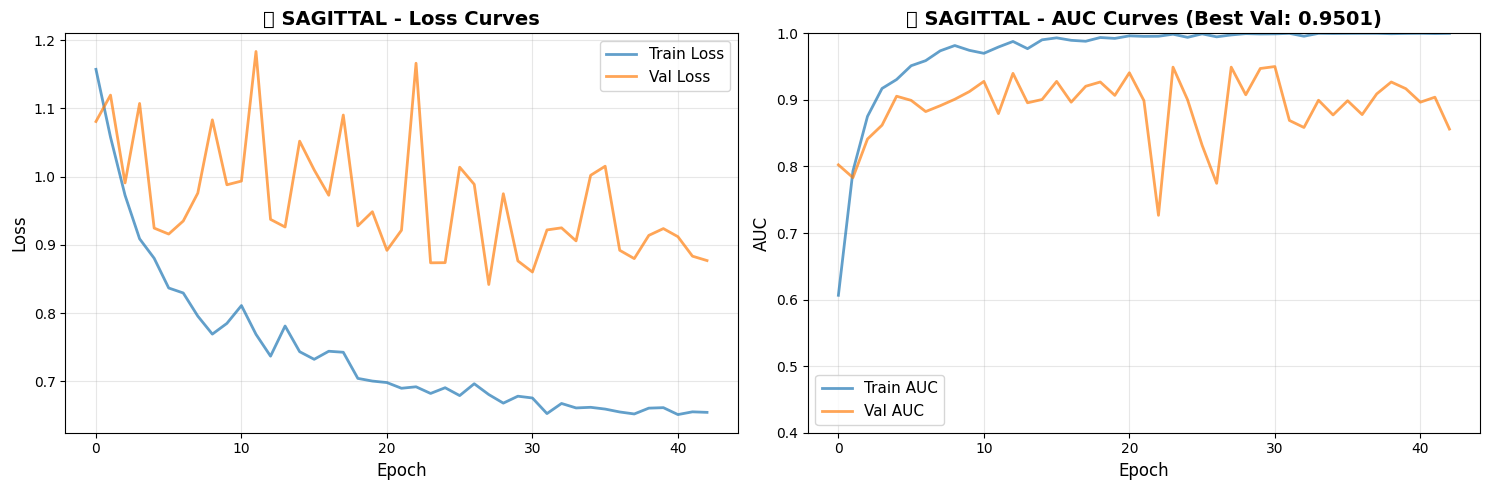

In [19]:
# Visualizar resultados del entrenamiento - SAGITTAL
if train_sagittal and history is not None:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

 # Gráfica 1: Training Loss vs Validation Loss
    axes[0].plot(history['train_loss'], label='Train Loss', linewidth=2, alpha=0.7)
    axes[0].plot(history['val_loss_objective'], label='Val Loss', linewidth=2, alpha=0.7)
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Loss', fontsize=12)
    axes[0].set_title(f' SAGITTAL - Loss Curves', fontsize=14, fontweight='bold')
    axes[0].legend(fontsize=11)
    axes[0].grid(True, alpha=0.3)

 # Gráfica 2: Training AUC vs Validation AUC
    axes[1].plot(history['train_auc'], label='Train AUC', linewidth=2, alpha=0.7)
    axes[1].plot(history['val_auc'], label='Val AUC', linewidth=2, alpha=0.7)
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('AUC', fontsize=12)
    axes[1].set_title(f' SAGITTAL - AUC Curves (Best Val: {best_auc:.4f})', fontsize=14, fontweight='bold')
    axes[1].legend(fontsize=11)
    axes[1].grid(True, alpha=0.3)
    axes[1].set_ylim([0.4, 1.0])

    plt.tight_layout()

 # Guardar figura
    plot_path = CHECKPOINT_DIR / f"training_curves_sagittal.png"
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    print(f" Gráficas guardadas en: {plot_path}\n")
    plt.show()

## 4⃣ Entrenar CORONAL

In [20]:
train_coronal = True  # Cambiar a True para entrenar

if train_coronal:
    plane = 'coronal'
    print(f"\n{'='*80}")
    print(f" ENTRENANDO CNN BASELINE: {plane.upper()}")
    print(f"{'='*80}\n")

 # Cargar configuración
    cfg = PLANE_SPECIFIC_CONFIG[plane]
    aug_mode = AUGMENTATION_MODE_PER_PLANE[plane]
    plane_pooling_mode = PLANE_CONFIG[plane].get('pooling_mode', 'attention')

 # Crear datasets
    train_indices_path = SLICE_INDICES_DIR / f"train_{plane}_indices.json"
    val_indices_path = SLICE_INDICES_DIR / f"val_{plane}_indices.json"

    train_dataset = OptimizedMRNetDataset(
        csv_path=DATA_PATH / 'train-acl.csv',
        data_root=DATA_PATH / 'train',
        plane=plane,
        indices_cache_path=train_indices_path,
        augmentation_mode=aug_mode
    )

    val_dataset = OptimizedMRNetDataset(
        csv_path=DATA_PATH / 'val-acl.csv',
        data_root=DATA_PATH / 'val',
        plane=plane,
        indices_cache_path=val_indices_path,
        augmentation_mode=None,
        transform=get_val_test_transform()
    )

 # Crear DataLoaders
    train_loader = DataLoader(
        train_dataset, batch_size=BATCH_SIZE, shuffle=True,
        num_workers=NUM_WORKERS, pin_memory=True
    )
    val_loader = DataLoader(
        val_dataset, batch_size=BATCH_SIZE, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=True
    )

    print(f" DataLoaders creados:")
    print(f"  Train: {len(train_loader)} batches ({len(train_dataset)} casos)")
    print(f"  Val: {len(val_loader)} batches ({len(val_dataset)} casos)\n")

 # Crear modelo CNN
    model = CNNMultiSliceClassifier(
        num_classes=NUM_CLASSES,
        pretrained=True,
        pooling_mode=plane_pooling_mode,
        dropout_input=cfg['dropout_input'],
        dropout_dense=cfg['dropout_dense']
    )

    model = nn.DataParallel(model, device_ids=VIT_GPU_IDS)
    model = model.to(device)

    print(f" Modelo CNN ResNet50 en GPUs: {VIT_GPU_IDS}\n")
    print(f"  Config: {cfg['status']}\n")

 # Entrenar
    history, best_auc, best_f1 = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        num_epochs=NUM_EPOCHS,
        device=device,
        save_dir=CHECKPOINT_DIR,
        plane_name=plane,
        learning_rate=cfg['learning_rate'],
        weight_decay=cfg['weight_decay'],
        label_smoothing=cfg.get('label_smoothing', 0.05),
        use_scheduler=cfg.get('use_scheduler', False),
        use_grad_clip=cfg.get('use_grad_clip', False),
        grad_clip_norm=cfg.get('grad_clip_norm', 1.0),
        early_stopping_patience=cfg.get('early_stopping_patience', 15),
        dropout_input=cfg['dropout_input'],
        dropout_dense=cfg['dropout_dense'],
        augmentation_mode=aug_mode,
        use_wandb=USE_WANDB,
        warmup_epochs=cfg.get('warmup_epochs', 3),
        use_lr_plateau_scheduler=cfg.get('use_lr_plateau_scheduler', False),
        lr_reduction_factor=cfg.get('lr_reduction_factor', 0.5),
        lr_plateau_patience=cfg.get('lr_plateau_patience', 5)
    )

    print(f"\n{'='*80}")
    print(f" CORONAL COMPLETADO (CNN ResNet50)")
    print(f"   Best AUC: {best_auc:.4f}")
    print(f"   Best F1: {best_f1:.4f}")
    print(f"{'='*80}\n")


 ENTRENANDO CNN BASELINE: CORONAL

 Dataset cargado: 875 casos
  Plane: coronal
  Augmentation: moderate
  Índices cacheados: ../data/slice_indices_final/train_coronal_indices.json
 Dataset cargado: 188 casos
  Plane: coronal
  Augmentation: None (usando transform directo)
  Índices cacheados: ../data/slice_indices_final/val_coronal_indices.json
 DataLoaders creados:
  Train: 14 batches (875 casos)
  Val: 3 batches (188 casos)



 Modelo CNN ResNet50 en GPUs: [0, 1, 2, 3]

  Config:  CNN ResNet50 - Moderate Aug + AGGRESSIVE Regularization + LR Annealing


ENTRENANDO MODELO: CORONAL
LR=0.0001, WD=0.0022, Scheduler=False, GradClip=True
Dropout: Input=0.47, Dense=0.37
Augmentation: moderate

 Class imbalance (pos_weight): 3.7814
   (Ratio negatives:positives)



 Weights & Biases inicializado para coronal

Epoch 1/150 (LR=1.00e-04): Train: Loss=1.2267, AUC=0.5044 | Val: Loss=1.1714, AUC=0.6840, F1=0.3971  Best AUC!
Epoch 2/150 (LR=1.00e-04): Train: Loss=1.1763, AUC=0.6187 | Val: Loss=1.2034, AUC=0.7231, F1=0.4412  Best AUC!
Epoch 3/150 (LR=1.00e-04): Train: Loss=1.0838, AUC=0.8099 | Val: Loss=1.1099, AUC=0.8310, F1=0.5192  Best AUC!
Epoch 4/150 (LR=1.00e-04): Train: Loss=1.0235, AUC=0.8781 | Val: Loss=1.0969, AUC=0.8754, F1=0.5231  Best AUC!
Epoch 5/150 (LR=1.00e-04): Train: Loss=0.9877, AUC=0.9090 | Val: Loss=1.1303, AUC=0.8704, F1=0.3956
Epoch 6/150 (LR=1.00e-04): Train: Loss=0.9390, AUC=0.9464 | Val: Loss=0.9892, AUC=0.9117, F1=0.6286  Best AUC!
Epoch 7/150 (LR=1.00e-04): Train: Loss=0.9019, AUC=0.9615 | Val: Loss=1.0662, AUC=0.8841, F1=0.6207
Epoch 8/150 (LR=1.00e-04): Train: Loss=0.8926, AUC=0.9648 | Val: Loss=1.0034, AUC=0.9041, F1=0.6400
Epoch 9/150 (LR=1.00e-04): Train: Loss=0.8728, AUC=0.9736 | Val: Loss=0.9796, AUC=0.9229, F1=0.6286 

epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
learning_rate,██████████████████▄▄▄▄▄▄▂▂▂▂▁▁
train_auc,▁▃▅▆▇▇▇███████████████████████
train_loss,█▇▆▅▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁
val_auc,▁▂▅▆▆▇▆▆▇▇▆▇▇▇▇▇▆▇▇█▇▇▆▆▅▆▆▆▆▆
val_f1,▁▂▃▃▁▅▅▅▅▃▂▆▆▇▆▇▆▅▇██▇▆▇█▇▇▇▇▇
val_loss,▇█▆▆▆▃▅▄▃▆▇▃▄▃▄▄▄▄▃▁▃▂▃▃▃▃▃▃▃▃
best_auc,0.9735
best_f1,0.80488
epoch,30
learning_rate,2e-05



 CORONAL COMPLETADO (CNN ResNet50)
   Best AUC: 0.9735
   Best F1: 0.8049



 Gráficas guardadas en: ../checkpoints/cnn_baseline_resnet50/training_curves_coronal.png



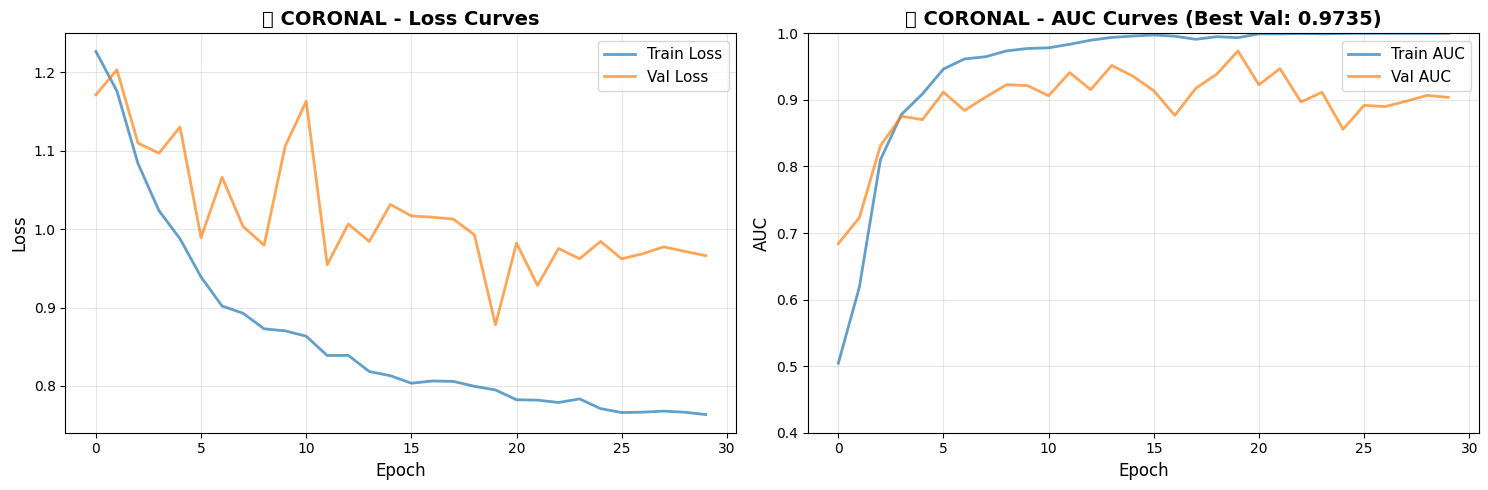

In [21]:
# Visualizar resultados del entrenamiento - CORONAL
if train_coronal and history is not None:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

 # Gráfica 1: Training Loss vs Validation Loss
    axes[0].plot(history['train_loss'], label='Train Loss', linewidth=2, alpha=0.7)
    axes[0].plot(history['val_loss_objective'], label='Val Loss', linewidth=2, alpha=0.7)
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Loss', fontsize=12)
    axes[0].set_title(f' CORONAL - Loss Curves', fontsize=14, fontweight='bold')
    axes[0].legend(fontsize=11)
    axes[0].grid(True, alpha=0.3)

 # Gráfica 2: Training AUC vs Validation AUC
    axes[1].plot(history['train_auc'], label='Train AUC', linewidth=2, alpha=0.7)
    axes[1].plot(history['val_auc'], label='Val AUC', linewidth=2, alpha=0.7)
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('AUC', fontsize=12)
    axes[1].set_title(f' CORONAL - AUC Curves (Best Val: {best_auc:.4f})', fontsize=14, fontweight='bold')
    axes[1].legend(fontsize=11)
    axes[1].grid(True, alpha=0.3)
    axes[1].set_ylim([0.4, 1.0])

    plt.tight_layout()

 # Guardar figura
    plot_path = CHECKPOINT_DIR / f"training_curves_coronal.png"
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    print(f" Gráficas guardadas en: {plot_path}\n")
    plt.show()

## 5⃣ Entrenar AXIAL

In [22]:
train_axial = True  # Cambiar a True para entrenar

if train_axial:
    plane = 'axial'
    print(f"\n{'='*80}")
    print(f" ENTRENANDO CNN BASELINE: {plane.upper()}")
    print(f"{'='*80}\n")

 # Cargar configuración
    cfg = PLANE_SPECIFIC_CONFIG[plane]
    aug_mode = AUGMENTATION_MODE_PER_PLANE[plane]
    plane_pooling_mode = PLANE_CONFIG[plane].get('pooling_mode', 'attention')

 # Crear datasets
    train_indices_path = SLICE_INDICES_DIR / f"train_{plane}_indices.json"
    val_indices_path = SLICE_INDICES_DIR / f"val_{plane}_indices.json"

    train_dataset = OptimizedMRNetDataset(
        csv_path=DATA_PATH / 'train-acl.csv',
        data_root=DATA_PATH / 'train',
        plane=plane,
        indices_cache_path=train_indices_path,
        augmentation_mode=aug_mode
    )

    val_dataset = OptimizedMRNetDataset(
        csv_path=DATA_PATH / 'val-acl.csv',
        data_root=DATA_PATH / 'val',
        plane=plane,
        indices_cache_path=val_indices_path,
        augmentation_mode=None,
        transform=get_val_test_transform()
    )

 # Crear DataLoaders
    train_loader = DataLoader(
        train_dataset, batch_size=BATCH_SIZE, shuffle=True,
        num_workers=NUM_WORKERS, pin_memory=True
    )
    val_loader = DataLoader(
        val_dataset, batch_size=BATCH_SIZE, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=True
    )

    print(f" DataLoaders creados:")
    print(f"  Train: {len(train_loader)} batches ({len(train_dataset)} casos)")
    print(f"  Val: {len(val_loader)} batches ({len(val_dataset)} casos)\n")

 # Crear modelo CNN
    model = CNNMultiSliceClassifier(
        num_classes=NUM_CLASSES,
        pretrained=True,
        pooling_mode=plane_pooling_mode,
        dropout_input=cfg['dropout_input'],
        dropout_dense=cfg['dropout_dense']
    )

    model = nn.DataParallel(model, device_ids=VIT_GPU_IDS)
    model = model.to(device)

    print(f" Modelo CNN ResNet50 en GPUs: {VIT_GPU_IDS}\n")
    print(f"  Config: {cfg['status']}\n")

 # Entrenar
    history, best_auc, best_f1 = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        num_epochs=NUM_EPOCHS,
        device=device,
        save_dir=CHECKPOINT_DIR,
        plane_name=plane,
        learning_rate=cfg['learning_rate'],
        weight_decay=cfg['weight_decay'],
        label_smoothing=cfg.get('label_smoothing', 0.05),
        use_scheduler=cfg.get('use_scheduler', False),
        use_grad_clip=cfg.get('use_grad_clip', False),
        grad_clip_norm=cfg.get('grad_clip_norm', 1.0),
        early_stopping_patience=cfg.get('early_stopping_patience', 15),
        dropout_input=cfg['dropout_input'],
        dropout_dense=cfg['dropout_dense'],
        augmentation_mode=aug_mode,
        use_wandb=USE_WANDB,
        warmup_epochs=cfg.get('warmup_epochs', 3),
        use_lr_plateau_scheduler=cfg.get('use_lr_plateau_scheduler', False),
        lr_reduction_factor=cfg.get('lr_reduction_factor', 0.5),
        lr_plateau_patience=cfg.get('lr_plateau_patience', 5)
    )

    print(f"\n{'='*80}")
    print(f" AXIAL COMPLETADO (CNN ResNet50)")
    print(f"   Best AUC: {best_auc:.4f}")
    print(f"   Best F1: {best_f1:.4f}")
    print(f"{'='*80}\n")


 ENTRENANDO CNN BASELINE: AXIAL

 Dataset cargado: 875 casos
  Plane: axial
  Augmentation: aggressive
  Índices cacheados: ../data/slice_indices_final/train_axial_indices.json
 Dataset cargado: 188 casos
  Plane: axial
  Augmentation: None (usando transform directo)
  Índices cacheados: ../data/slice_indices_final/val_axial_indices.json
 DataLoaders creados:
  Train: 14 batches (875 casos)
  Val: 3 batches (188 casos)

 Modelo CNN ResNet50 en GPUs: [0, 1, 2, 3]

  Config:  CNN ResNet50 - Aggressive Aug + Strong Regularization + LR Annealing


ENTRENANDO MODELO: AXIAL
LR=0.00011, WD=0.0017, Scheduler=False, GradClip=True
Dropout: Input=0.42, Dense=0.32
Augmentation: aggressive

 Class imbalance (pos_weight): 3.7814
   (Ratio negatives:positives)



 Weights & Biases inicializado para axial

Epoch 1/150 (LR=1.10e-04): Train: Loss=1.1109, AUC=0.7275 | Val: Loss=1.4582, AUC=0.7493, F1=0.3735  Best AUC!
Epoch 2/150 (LR=1.10e-04): Train: Loss=1.0255, AUC=0.8329 | Val: Loss=1.0393, AUC=0.8182, F1=0.4348  Best AUC!
Epoch 3/150 (LR=1.10e-04): Train: Loss=0.9421, AUC=0.8910 | Val: Loss=1.2162, AUC=0.8792, F1=0.5938  Best AUC!
Epoch 4/150 (LR=1.10e-04): Train: Loss=0.8753, AUC=0.9344 | Val: Loss=0.9641, AUC=0.9295, F1=0.6286  Best AUC!
Epoch 5/150 (LR=1.10e-04): Train: Loss=0.8357, AUC=0.9452 | Val: Loss=0.9330, AUC=0.9622, F1=0.6792  Best AUC!
Epoch 6/150 (LR=1.10e-04): Train: Loss=0.8026, AUC=0.9609 | Val: Loss=0.8596, AUC=0.9704, F1=0.7000  Best AUC!
Epoch 7/150 (LR=1.10e-04): Train: Loss=0.7831, AUC=0.9707 | Val: Loss=0.9880, AUC=0.9238, F1=0.5812
Epoch 8/150 (LR=1.10e-04): Train: Loss=0.7950, AUC=0.9728 | Val: Loss=1.0507, AUC=0.9015, F1=0.6742
Epoch 9/150 (LR=1.10e-04): Train: Loss=0.7812, AUC=0.9762 | Val: Loss=1.0215, AUC=0.9172, F

epoch,▁▁▂▂▃▃▃▄▄▅▅▆▆▆▇▇██
learning_rate,███████████▃▃▃▃▃▃▁
train_auc,▁▄▅▆▇▇▇▇▇▇▇███████
train_loss,█▇▅▄▄▃▃▃▃▃▃▂▂▂▂▁▁▁
val_auc,▁▃▅▇██▇▆▆▅▇▇▅▇▅▆▇▇
val_f1,▁▂▅▆▇█▅▇▇▇█▇▇█▇▇▇█
val_loss,█▃▅▂▂▁▃▃▃▃▂▂▃▂▂▃▂▂
best_auc,0.97039
best_f1,0.7
epoch,18
learning_rate,3e-05



 AXIAL COMPLETADO (CNN ResNet50)
   Best AUC: 0.9704
   Best F1: 0.7000



 Gráficas guardadas en: ../checkpoints/cnn_baseline_resnet50/training_curves_axial.png



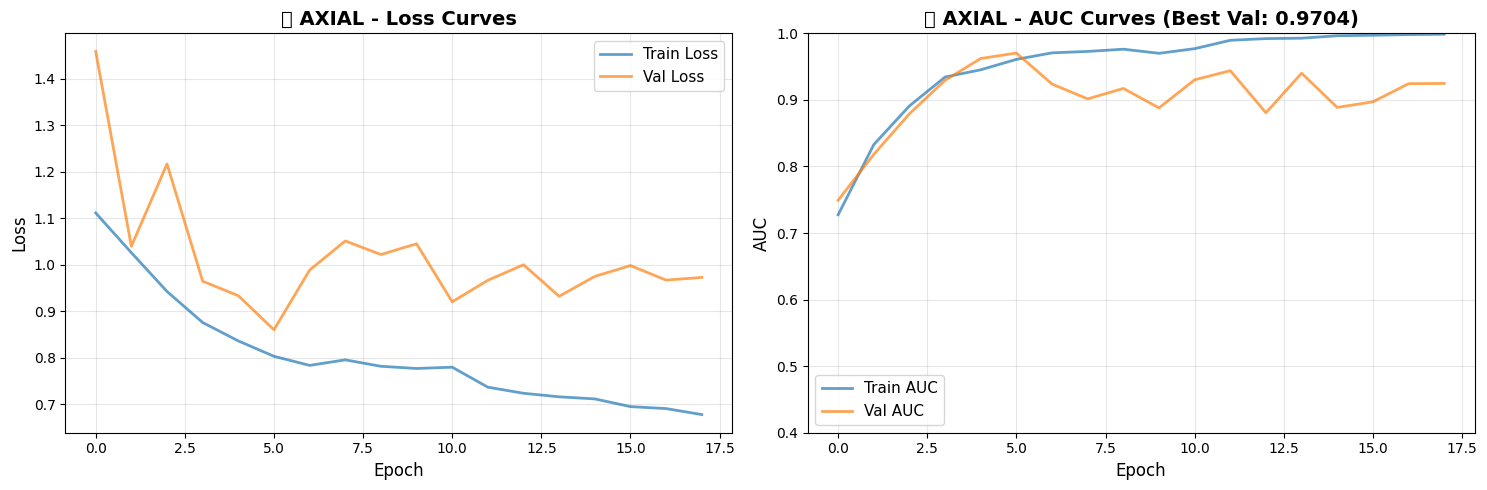

In [23]:
# Visualizar resultados del entrenamiento - AXIAL
if train_axial and history is not None:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

 # Gráfica 1: Training Loss vs Validation Loss
    axes[0].plot(history['train_loss'], label='Train Loss', linewidth=2, alpha=0.7)
    axes[0].plot(history['val_loss_objective'], label='Val Loss', linewidth=2, alpha=0.7)
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Loss', fontsize=12)
    axes[0].set_title(f' AXIAL - Loss Curves', fontsize=14, fontweight='bold')
    axes[0].legend(fontsize=11)
    axes[0].grid(True, alpha=0.3)

 # Gráfica 2: Training AUC vs Validation AUC
    axes[1].plot(history['train_auc'], label='Train AUC', linewidth=2, alpha=0.7)
    axes[1].plot(history['val_auc'], label='Val AUC', linewidth=2, alpha=0.7)
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('AUC', fontsize=12)
    axes[1].set_title(f' AXIAL - AUC Curves (Best Val: {best_auc:.4f})', fontsize=14, fontweight='bold')
    axes[1].legend(fontsize=11)
    axes[1].grid(True, alpha=0.3)
    axes[1].set_ylim([0.4, 1.0])

    plt.tight_layout()

 # Guardar figura
    plot_path = CHECKPOINT_DIR / f"training_curves_axial.png"
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    print(f" Gráficas guardadas en: {plot_path}\n")
    plt.show()

## 6⃣ Ensamble CNN - Cargar Modelos Entrenados

In [24]:
# Cargar los 3 modelos entrenados
print(f"\n{'='*80}")
print(f" CARGANDO MODELOS ENTRENADOS PARA ENSAMBLE")
print(f"{'='*80}\n")

models_ensemble = {}

for plane in PLANES:
    checkpoint_path = CHECKPOINT_DIR / f"best_{plane}_auc.pth"

    if not checkpoint_path.exists():
        print(f" Checkpoint no encontrado para {plane}: {checkpoint_path}")
        continue

 # Crear modelo
    model = CNNMultiSliceClassifier(
        num_classes=NUM_CLASSES,
        pretrained=True,
        pooling_mode=PLANE_CONFIG[plane].get('pooling_mode', 'attention'),
        dropout_input=PLANE_SPECIFIC_CONFIG[plane]['dropout_input'],
        dropout_dense=PLANE_SPECIFIC_CONFIG[plane]['dropout_dense']
    )

 # Cargar checkpoint
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])

 # Mover a GPU y poner en eval mode
    model = model.to(device)
    model.eval()

    models_ensemble[plane] = model

    print(f" {plane.upper()} cargado exitosamente")
    print(f"  Best Val AUC: {checkpoint['val_auc']:.4f}")
    print(f"  Best Val F1:  {checkpoint['val_f1']:.4f}\n")

print(f"{'='*80}")
print(f" Total de modelos cargados: {len(models_ensemble)}/{len(PLANES)}")
print(f"{'='*80}\n")


 CARGANDO MODELOS ENTRENADOS PARA ENSAMBLE

 SAGITTAL cargado exitosamente
  Best Val AUC: 0.9501
  Best Val F1:  0.7711

 CORONAL cargado exitosamente
  Best Val AUC: 0.9735
  Best Val F1:  0.8049

 AXIAL cargado exitosamente
  Best Val AUC: 0.9704
  Best Val F1:  0.7000

 Total de modelos cargados: 3/3



In [25]:
# Cargar test datasets para cada plano
print(f"{'='*80}")
print(f" CARGANDO TEST DATASETS")
print(f"{'='*80}\n")

test_loaders = {}
test_datasets = {}

for plane in PLANES:
    test_indices_path = SLICE_INDICES_DIR / f"test_{plane}_indices.json"

    test_dataset = OptimizedMRNetDataset(
        csv_path=DATA_PATH / 'test-acl.csv',
        data_root=DATA_PATH / 'test',
        plane=plane,
        indices_cache_path=test_indices_path,
        augmentation_mode=None,
        transform=get_val_test_transform()
    )

    test_loader = DataLoader(
        test_dataset, batch_size=BATCH_SIZE, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=True
    )

    test_loaders[plane] = test_loader
    test_datasets[plane] = test_dataset

    print(f" {plane.upper()} test dataset cargado: {len(test_dataset)} casos")

print(f"\n{'='*80}")
print(f" Total de test cases por plano: {len(test_datasets['sagittal'])}")
print(f"{'='*80}\n")

 CARGANDO TEST DATASETS

 Dataset cargado: 187 casos
  Plane: sagittal
  Augmentation: None (usando transform directo)
  Índices cacheados: ../data/slice_indices_final/test_sagittal_indices.json
 SAGITTAL test dataset cargado: 187 casos
 Dataset cargado: 187 casos
  Plane: coronal
  Augmentation: None (usando transform directo)
  Índices cacheados: ../data/slice_indices_final/test_coronal_indices.json
 CORONAL test dataset cargado: 187 casos
 Dataset cargado: 187 casos
  Plane: axial
  Augmentation: None (usando transform directo)
  Índices cacheados: ../data/slice_indices_final/test_axial_indices.json
 AXIAL test dataset cargado: 187 casos

 Total de test cases por plano: 187



In [26]:
# Hacer predicciones en VALIDACIÓN y TEST
print(f"{'='*100}")
print(f" HACIENDO PREDICCIONES EN VALIDACIÓN Y TEST")
print(f"{'='*100}\n")

# Diccionarios para almacenar predicciones
probs_per_plane_val = {plane: [] for plane in PLANES}
probs_per_plane_test = {plane: [] for plane in PLANES}
targets_val = []
targets_test = []

# ==========================================
# PREDICCIONES EN VALIDACIÓN
# ==========================================
print(" VALIDACIÓN SET:")
for plane in PLANES:
    print(f"  Procesando {plane.upper()}...", end=' ')

    model = models_ensemble[plane]
    val_loader = val_loaders[plane] if 'val_loaders' in locals() else None

 # Si no hay val_loaders, crearlos ahora
    if val_loader is None:
        val_indices_path = SLICE_INDICES_DIR / f"val_{plane}_indices.json"
        val_dataset = OptimizedMRNetDataset(
            csv_path=DATA_PATH / 'val-acl.csv',
            data_root=DATA_PATH / 'val',
            plane=plane,
            indices_cache_path=val_indices_path,
            augmentation_mode=None,
            transform=get_val_test_transform()
        )
        val_loader = DataLoader(
            val_dataset, batch_size=BATCH_SIZE, shuffle=False,
            num_workers=NUM_WORKERS, pin_memory=True
        )

    plane_probs_val = []
    plane_targets_val = []

    with torch.no_grad():
        for slices, targets, _ in val_loader:
            slices = slices.to(device)
            targets = targets.to(device).unsqueeze(-1)

            outputs = model(slices)
            logits = outputs[0] if isinstance(outputs, tuple) else outputs
            probs = torch.sigmoid(logits).detach().cpu().numpy().flatten()

            plane_probs_val.extend(probs)
            plane_targets_val.extend(targets.detach().cpu().numpy().flatten())

    probs_per_plane_val[plane] = np.array(plane_probs_val)
    if len(targets_val) == 0:
        targets_val = np.array(plane_targets_val)

    val_auc = roc_auc_score(plane_targets_val, plane_probs_val)
    print(f" AUC: {val_auc:.4f}")

print(f"\n TEST SET:")
for plane in PLANES:
    print(f"  Procesando {plane.upper()}...", end=' ')

    model = models_ensemble[plane]

    test_indices_path = SLICE_INDICES_DIR / f"test_{plane}_indices.json"
    test_dataset = OptimizedMRNetDataset(
        csv_path=DATA_PATH / 'test-acl.csv',
        data_root=DATA_PATH / 'test',
        plane=plane,
        indices_cache_path=test_indices_path,
        augmentation_mode=None,
        transform=get_val_test_transform()
    )
    test_loader = DataLoader(
        test_dataset, batch_size=BATCH_SIZE, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=True
    )

    plane_probs_test = []
    plane_targets_test = []

    with torch.no_grad():
        for slices, targets, _ in test_loader:
            slices = slices.to(device)
            targets = targets.to(device).unsqueeze(-1)

            outputs = model(slices)
            logits = outputs[0] if isinstance(outputs, tuple) else outputs
            probs = torch.sigmoid(logits).detach().cpu().numpy().flatten()

            plane_probs_test.extend(probs)
            plane_targets_test.extend(targets.detach().cpu().numpy().flatten())

    probs_per_plane_test[plane] = np.array(plane_probs_test)
    if len(targets_test) == 0:
        targets_test = np.array(plane_targets_test)

    test_auc = roc_auc_score(plane_targets_test, plane_probs_test)
    print(f" AUC: {test_auc:.4f}")

# Crear ensambles (promedio de probabilidades)
ensemble_probs_val = np.mean([probs_per_plane_val[p] for p in PLANES], axis=0)
ensemble_probs_test = np.mean([probs_per_plane_test[p] for p in PLANES], axis=0)

ensemble_auc_val = roc_auc_score(targets_val, ensemble_probs_val)
ensemble_auc_test = roc_auc_score(targets_test, ensemble_probs_test)

print(f"\n{'='*100}")
print(f" ENSAMBLE (PROMEDIO):")
print(f"   Val AUC: {ensemble_auc_val:.4f}")
print(f"   Test AUC: {ensemble_auc_test:.4f}")
print(f"{'='*100}\n")

 HACIENDO PREDICCIONES EN VALIDACIÓN Y TEST

 VALIDACIÓN SET:
  Procesando SAGITTAL...  Dataset cargado: 188 casos
  Plane: sagittal
  Augmentation: None (usando transform directo)
  Índices cacheados: ../data/slice_indices_final/val_sagittal_indices.json
 AUC: 0.9501
  Procesando CORONAL...  Dataset cargado: 188 casos
  Plane: coronal
  Augmentation: None (usando transform directo)
  Índices cacheados: ../data/slice_indices_final/val_coronal_indices.json
 AUC: 0.9735
  Procesando AXIAL...  Dataset cargado: 188 casos
  Plane: axial
  Augmentation: None (usando transform directo)
  Índices cacheados: ../data/slice_indices_final/val_axial_indices.json
 AUC: 0.9704

 TEST SET:
  Procesando SAGITTAL...  Dataset cargado: 187 casos
  Plane: sagittal
  Augmentation: None (usando transform directo)
  Índices cacheados: ../data/slice_indices_final/test_sagittal_indices.json
 AUC: 0.8679
  Procesando CORONAL...  Dataset cargado: 187 casos
  Plane: coronal
  Augmentation: None (usando transform d

In [27]:
# Calibración de threshold en VALIDACIÓN
from sklearn.metrics import confusion_matrix, precision_score, recall_score

print(f"\n{'='*100}")
print(f" CALIBRACIÓN DE THRESHOLD EN VALIDACIÓN")
print(f"{'='*100}\n")

# Definir rango de thresholds y función auxiliar
THRESHOLD_RANGE = np.arange(0.30, 0.71, 0.01)

def compute_metrics(probs, targets, threshold=0.5):
    """Calcula métricas para un threshold dado"""
    preds = (probs >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(targets, preds).ravel()

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    youdens = recall + specificity - 1

    return {
        'tp': tp, 'fp': fp, 'fn': fn, 'tn': tn,
        'precision': precision, 'recall': recall, 'specificity': specificity,
        'f1': f1, 'youdens': youdens, 'auc': roc_auc_score(targets, probs)
    }

# Buscar threshold óptimo para cada criterio
metrics_ensemble = {}

print("Buscando thresholds óptimos...")
for threshold in THRESHOLD_RANGE:
    metrics_ensemble[threshold] = compute_metrics(ensemble_probs_val, targets_val, threshold)

# OPCIÓN 1: Maximizar F1
best_threshold_f1 = max(metrics_ensemble.keys(), key=lambda t: metrics_ensemble[t]['f1'])
metrics_opt1 = metrics_ensemble[best_threshold_f1]

# OPCIÓN 2: Maximizar Recall (mantener Precision ≥ 0.75)
MIN_PRECISION = 0.75
candidates_recall = [t for t in metrics_ensemble.keys()
                     if metrics_ensemble[t]['precision'] >= MIN_PRECISION]
if candidates_recall:
    best_threshold_recall = max(candidates_recall,
                               key=lambda t: metrics_ensemble[t]['recall'])
    metrics_opt2 = metrics_ensemble[best_threshold_recall]
else:
    best_threshold_recall = None
    metrics_opt2 = None

# OPCIÓN 3: Maximizar Youden's Index
best_threshold_youdens = max(metrics_ensemble.keys(),
                             key=lambda t: metrics_ensemble[t]['youdens'])
metrics_opt3 = metrics_ensemble[best_threshold_youdens]

# Mostrar resultados
print(f"\n{'='*100}")
print(f" OPCIONES DE THRESHOLD (VALIDACIÓN)")
print(f"{'='*100}\n")

print(f"1⃣  OPCIÓN 1: Maximizar F1")
print(f"    Threshold: {best_threshold_f1:.2f}")
print(f"    F1-Score:     {metrics_opt1['f1']:.4f}")
print(f"    Precision:    {metrics_opt1['precision']:.4f}")
print(f"    Recall:       {metrics_opt1['recall']:.4f}")
print(f"    Specificity:  {metrics_opt1['specificity']:.4f}")
print(f"    Youden's J:   {metrics_opt1['youdens']:.4f}\n")

print(f"2⃣  OPCIÓN 2: Maximizar RECALL (Precision ≥ {MIN_PRECISION:.2f})")
if metrics_opt2 is not None:
    print(f"    Threshold: {best_threshold_recall:.2f}")
    print(f"    F1-Score:     {metrics_opt2['f1']:.4f}")
    print(f"    Precision:    {metrics_opt2['precision']:.4f}")
    print(f"    Recall:       {metrics_opt2['recall']:.4f}")
    print(f"    Specificity:  {metrics_opt2['specificity']:.4f}")
    print(f"    Youden's J:   {metrics_opt2['youdens']:.4f}\n")
else:
    print(f"      No hay threshold que cumpla Precision ≥ {MIN_PRECISION:.2f}\n")
    best_threshold_recall = best_threshold_youdens
    metrics_opt2 = metrics_opt3

print(f"3⃣  OPCIÓN 3: Maximizar YOUDEN'S INDEX")
print(f"    Threshold: {best_threshold_youdens:.2f}")
print(f"    F1-Score:     {metrics_opt3['f1']:.4f}")
print(f"    Precision:    {metrics_opt3['precision']:.4f}")
print(f"    Recall:       {metrics_opt3['recall']:.4f}")
print(f"    Specificity:  {metrics_opt3['specificity']:.4f}")
print(f"    Youden's J:   {metrics_opt3['youdens']:.4f}\n")

print(f"{'='*100}\n")


 CALIBRACIÓN DE THRESHOLD EN VALIDACIÓN

Buscando thresholds óptimos...

 OPCIONES DE THRESHOLD (VALIDACIÓN)

1⃣  OPCIÓN 1: Maximizar F1
    Threshold: 0.57
    F1-Score:     0.8831
    Precision:    0.8293
    Recall:       0.9444
    Specificity:  0.9539
    Youden's J:   0.8984

2⃣  OPCIÓN 2: Maximizar RECALL (Precision ≥ 0.75)
    Threshold: 0.54
    F1-Score:     0.8537
    Precision:    0.7609
    Recall:       0.9722
    Specificity:  0.9276
    Youden's J:   0.8999

3⃣  OPCIÓN 3: Maximizar YOUDEN'S INDEX
    Threshold: 0.52
    F1-Score:     0.8372
    Precision:    0.7200
    Recall:       1.0000
    Specificity:  0.9079
    Youden's J:   0.9079





 MATRICES DE CONFUSIÓN - VALIDACIÓN



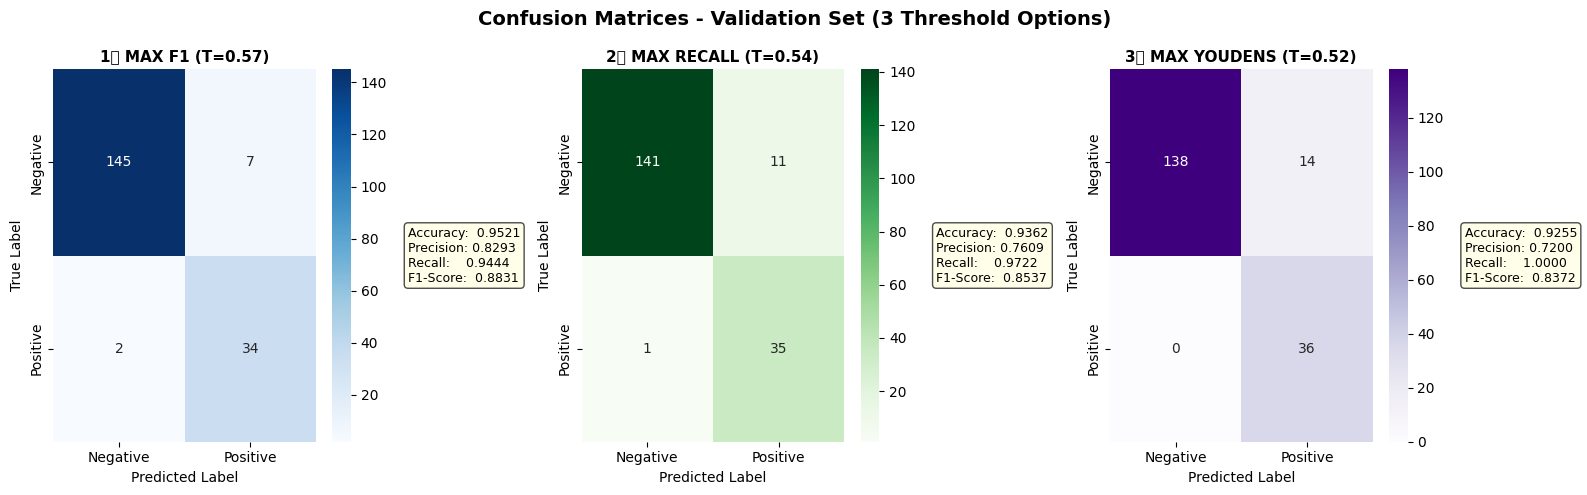

 Matrices de confusión (validación) generadas

 THRESHOLD SELECCIONADO: 0.57 (1⃣ MAX F1)



In [28]:
# MATRICES DE CONFUSIÓN - VALIDACIÓN (3 OPCIONES)
import seaborn as sns

print(f"\n{'='*100}")
print(f" MATRICES DE CONFUSIÓN - VALIDACIÓN")
print(f"{'='*100}\n")

# Generar predicciones para cada opción
preds_val_opt1 = (ensemble_probs_val >= best_threshold_f1).astype(int)
cm_val_opt1 = confusion_matrix(targets_val, preds_val_opt1)

preds_val_opt2 = (ensemble_probs_val >= best_threshold_recall).astype(int)
cm_val_opt2 = confusion_matrix(targets_val, preds_val_opt2)

preds_val_opt3 = (ensemble_probs_val >= best_threshold_youdens).astype(int)
cm_val_opt3 = confusion_matrix(targets_val, preds_val_opt3)

# Visualizar matrices
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Confusion Matrices - Validation Set (3 Threshold Options)', fontsize=14, fontweight='bold')

colors_opts = ['Blues', 'Greens', 'Purples']
thresholds_vals = [best_threshold_f1, best_threshold_recall, best_threshold_youdens]
cms_val = [cm_val_opt1, cm_val_opt2, cm_val_opt3]
metrics_opts = [metrics_opt1, metrics_opt2, metrics_opt3]
titles = [
    f'1⃣ MAX F1 (T={best_threshold_f1:.2f})',
    f'2⃣ MAX RECALL (T={best_threshold_recall:.2f})',
    f'3⃣ MAX YOUDENS (T={best_threshold_youdens:.2f})'
]

for idx, (ax, cm, color_map, title, metrics) in enumerate(zip(axes, cms_val, colors_opts, titles, metrics_opts)):
    sns.heatmap(cm, annot=True, fmt='d', cmap=color_map, ax=ax, cbar=True,
                xticklabels=['Negative', 'Positive'],
                yticklabels=['Negative', 'Positive'])
    ax.set_ylabel('True Label', fontsize=10)
    ax.set_xlabel('Predicted Label', fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold')

 # Calcular accuracy
    acc = (metrics['tp'] + metrics['tn']) / (metrics['tp'] + metrics['tn'] + metrics['fp'] + metrics['fn'])
    metrics_text = f"""Accuracy:  {acc:.4f}
Precision: {metrics['precision']:.4f}
Recall:    {metrics['recall']:.4f}
F1-Score:  {metrics['f1']:.4f}"""
    ax.text(1.35, 0.5, metrics_text, fontsize=9, bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.7),
            transform=ax.transAxes, verticalalignment='center')

plt.tight_layout()
plt.show()

print(" Matrices de confusión (validación) generadas\n")

# Guardar best_threshold como el que elegimos (por defecto, F1)
SELECTED_THRESHOLD = best_threshold_f1
SELECTED_OPTION = "1⃣ MAX F1"
print(f" THRESHOLD SELECCIONADO: {SELECTED_THRESHOLD:.2f} ({SELECTED_OPTION})\n")


 MATRICES DE CONFUSIÓN - TEST SET (con umbral calibrado)



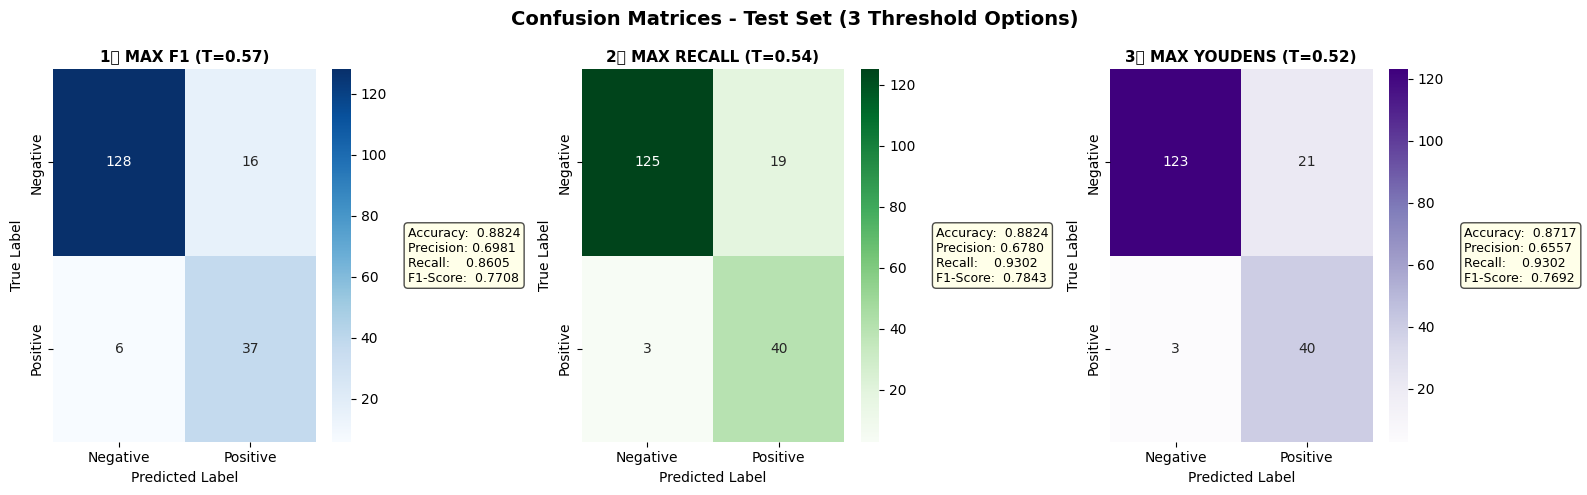

 Matrices de confusión (test) generadas



In [29]:
# MATRICES DE CONFUSIÓN - TEST (3 OPCIONES) - CON THRESHOLD CALIBRADO
print(f"\n{'='*100}")
print(f" MATRICES DE CONFUSIÓN - TEST SET (con umbral calibrado)")
print(f"{'='*100}\n")

# Generar predicciones para cada opción EN TEST
preds_test_opt1 = (ensemble_probs_test >= best_threshold_f1).astype(int)
cm_test_opt1 = confusion_matrix(targets_test, preds_test_opt1)

preds_test_opt2 = (ensemble_probs_test >= best_threshold_recall).astype(int)
cm_test_opt2 = confusion_matrix(targets_test, preds_test_opt2)

preds_test_opt3 = (ensemble_probs_test >= best_threshold_youdens).astype(int)
cm_test_opt3 = confusion_matrix(targets_test, preds_test_opt3)

# Calcular métricas en test
metrics_test_opt1 = compute_metrics(ensemble_probs_test, targets_test, best_threshold_f1)
metrics_test_opt2 = compute_metrics(ensemble_probs_test, targets_test, best_threshold_recall)
metrics_test_opt3 = compute_metrics(ensemble_probs_test, targets_test, best_threshold_youdens)

# Visualizar matrices
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Confusion Matrices - Test Set (3 Threshold Options)', fontsize=14, fontweight='bold')

cms_test = [cm_test_opt1, cm_test_opt2, cm_test_opt3]
metrics_test_opts = [metrics_test_opt1, metrics_test_opt2, metrics_test_opt3]

for idx, (ax, cm, color_map, title, metrics) in enumerate(zip(axes, cms_test, colors_opts, titles, metrics_test_opts)):
    sns.heatmap(cm, annot=True, fmt='d', cmap=color_map, ax=ax, cbar=True,
                xticklabels=['Negative', 'Positive'],
                yticklabels=['Negative', 'Positive'])
    ax.set_ylabel('True Label', fontsize=10)
    ax.set_xlabel('Predicted Label', fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold')

 # Calcular accuracy
    acc = (metrics['tp'] + metrics['tn']) / (metrics['tp'] + metrics['tn'] + metrics['fp'] + metrics['fn'])
    metrics_text = f"""Accuracy:  {acc:.4f}
Precision: {metrics['precision']:.4f}
Recall:    {metrics['recall']:.4f}
F1-Score:  {metrics['f1']:.4f}"""
    ax.text(1.35, 0.5, metrics_text, fontsize=9, bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.7),
            transform=ax.transAxes, verticalalignment='center')

plt.tight_layout()
plt.show()

print(" Matrices de confusión (test) generadas\n")


 ROC CURVES - ENSEMBLE CNN



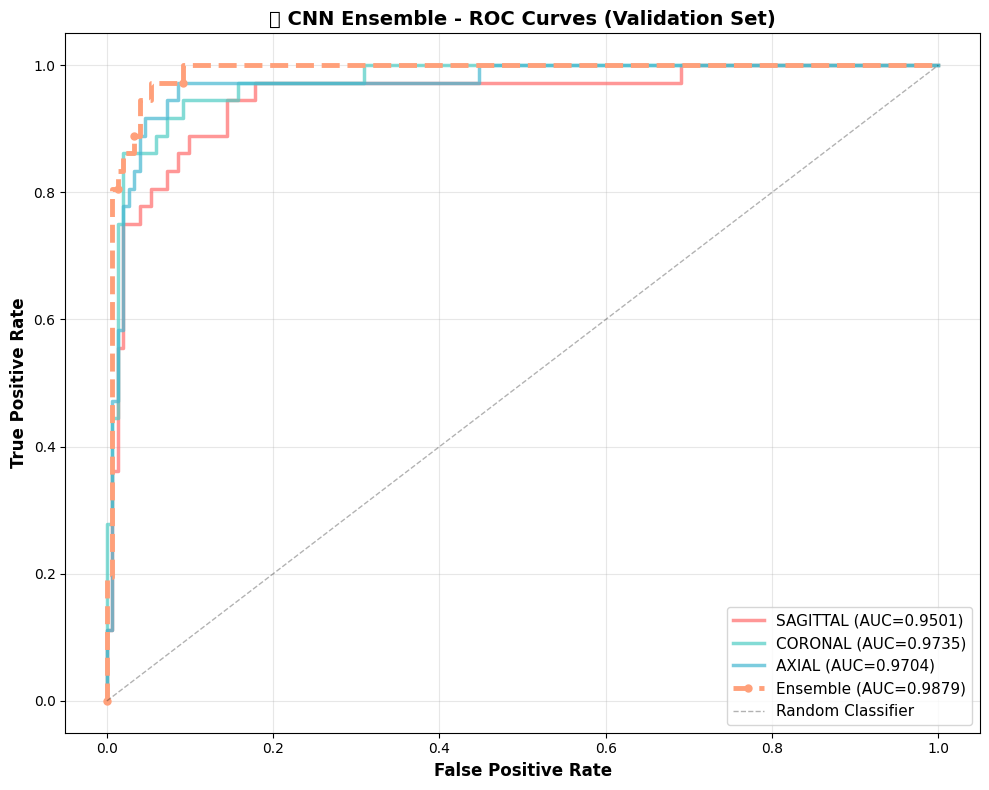

 ROC curves generadas


 RESUMEN COMPARATIVO: VALIDACIÓN vs TEST

         Option Threshold Val_AUC Val_F1 Val_Recall Test_AUC Test_F1 Test_Recall
     1⃣ MAX F1      0.57  0.9879 0.8831     0.9444   0.9432  0.7708      0.8605
 2⃣ MAX RECALL      0.54  0.9879 0.8537     0.9722   0.9432  0.7843      0.9302
3⃣ MAX YOUDENS      0.52  0.9879 0.8372     1.0000   0.9432  0.7692      0.9302

 ENSAMBLE CNN COMPLETADO CON THRESHOLD CALIBRADO

 Resultados guardados en: ../checkpoints/cnn_baseline_resnet50/ensemble_results_calibrated.json



In [30]:
# ROC CURVES Y RESUMEN FINAL
from sklearn.metrics import roc_curve

print(f"\n{'='*100}")
print(f" ROC CURVES - ENSEMBLE CNN")
print(f"{'='*100}\n")

# Crear figura con ROC curves
fig, ax = plt.subplots(figsize=(10, 8))

# ROC individual por plano
colors_planes = ['#FF6B6B', '#4ECDC4', '#45B7D1']
for i, plane in enumerate(PLANES):
    fpr, tpr, _ = roc_curve(targets_val, probs_per_plane_val[plane])
    plane_auc = roc_auc_score(targets_val, probs_per_plane_val[plane])
    ax.plot(fpr, tpr, linewidth=2.5, label=f'{plane.upper()} (AUC={plane_auc:.4f})', color=colors_planes[i], alpha=0.7)

# ROC Ensemble
fpr_ens, tpr_ens, _ = roc_curve(targets_val, ensemble_probs_val)
ax.plot(fpr_ens, tpr_ens, linewidth=3.5, label=f'Ensemble (AUC={ensemble_auc_val:.4f})',
        color='#FFA07A', linestyle='--', marker='o', markersize=5, markevery=5)

# Línea diagonal
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.3, label='Random Classifier')

ax.set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
ax.set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')
ax.set_title(' CNN Ensemble - ROC Curves (Validation Set)', fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='lower right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(" ROC curves generadas\n")

# TABLA COMPARATIVA: VALIDACIÓN vs TEST
print(f"\n{'='*100}")
print(f" RESUMEN COMPARATIVO: VALIDACIÓN vs TEST")
print(f"{'='*100}\n")

summary_data = []

# Opción 1
acc_val_opt1 = (metrics_opt1['tp'] + metrics_opt1['tn']) / (metrics_opt1['tp'] + metrics_opt1['tn'] + metrics_opt1['fp'] + metrics_opt1['fn'])
acc_test_opt1 = (metrics_test_opt1['tp'] + metrics_test_opt1['tn']) / (metrics_test_opt1['tp'] + metrics_test_opt1['tn'] + metrics_test_opt1['fp'] + metrics_test_opt1['fn'])

summary_data.append({
    'Option': '1⃣ MAX F1',
    'Threshold': f'{best_threshold_f1:.2f}',
    'Val_AUC': f"{metrics_opt1['auc']:.4f}",
    'Val_F1': f"{metrics_opt1['f1']:.4f}",
    'Val_Recall': f"{metrics_opt1['recall']:.4f}",
    'Test_AUC': f"{metrics_test_opt1['auc']:.4f}",
    'Test_F1': f"{metrics_test_opt1['f1']:.4f}",
    'Test_Recall': f"{metrics_test_opt1['recall']:.4f}"
})

# Opción 2
acc_val_opt2 = (metrics_opt2['tp'] + metrics_opt2['tn']) / (metrics_opt2['tp'] + metrics_opt2['tn'] + metrics_opt2['fp'] + metrics_opt2['fn'])
acc_test_opt2 = (metrics_test_opt2['tp'] + metrics_test_opt2['tn']) / (metrics_test_opt2['tp'] + metrics_test_opt2['tn'] + metrics_test_opt2['fp'] + metrics_test_opt2['fn'])

summary_data.append({
    'Option': '2⃣ MAX RECALL',
    'Threshold': f'{best_threshold_recall:.2f}',
    'Val_AUC': f"{metrics_opt2['auc']:.4f}",
    'Val_F1': f"{metrics_opt2['f1']:.4f}",
    'Val_Recall': f"{metrics_opt2['recall']:.4f}",
    'Test_AUC': f"{metrics_test_opt2['auc']:.4f}",
    'Test_F1': f"{metrics_test_opt2['f1']:.4f}",
    'Test_Recall': f"{metrics_test_opt2['recall']:.4f}"
})

# Opción 3
acc_val_opt3 = (metrics_opt3['tp'] + metrics_opt3['tn']) / (metrics_opt3['tp'] + metrics_opt3['tn'] + metrics_opt3['fp'] + metrics_opt3['fn'])
acc_test_opt3 = (metrics_test_opt3['tp'] + metrics_test_opt3['tn']) / (metrics_test_opt3['tp'] + metrics_test_opt3['tn'] + metrics_test_opt3['fp'] + metrics_test_opt3['fn'])

summary_data.append({
    'Option': '3⃣ MAX YOUDENS',
    'Threshold': f'{best_threshold_youdens:.2f}',
    'Val_AUC': f"{metrics_opt3['auc']:.4f}",
    'Val_F1': f"{metrics_opt3['f1']:.4f}",
    'Val_Recall': f"{metrics_opt3['recall']:.4f}",
    'Test_AUC': f"{metrics_test_opt3['auc']:.4f}",
    'Test_F1': f"{metrics_test_opt3['f1']:.4f}",
    'Test_Recall': f"{metrics_test_opt3['recall']:.4f}"
})

df_summary = pd.DataFrame(summary_data)
print(df_summary.to_string(index=False))

print(f"\n{'='*100}")
print(f" ENSAMBLE CNN COMPLETADO CON THRESHOLD CALIBRADO")
print(f"{'='*100}\n")

# Guardar resultados en JSON
results_summary = {
    'model': 'CNN ResNet50 Ensemble (with Threshold Calibration)',
    'selected_threshold': float(SELECTED_THRESHOLD),
    'selected_option': str(SELECTED_OPTION),
    'validation': {
        'auc': float(metrics_opt1['auc']),
        'f1': float(metrics_opt1['f1']),
        'precision': float(metrics_opt1['precision']),
        'recall': float(metrics_opt1['recall']),
        'specificity': float(metrics_opt1['specificity']),
        'youdens': float(metrics_opt1['youdens'])
    },
    'test': {
        'auc': float(metrics_test_opt1['auc']),
        'f1': float(metrics_test_opt1['f1']),
        'precision': float(metrics_test_opt1['precision']),
        'recall': float(metrics_test_opt1['recall']),
        'specificity': float(metrics_test_opt1['specificity']),
        'youdens': float(metrics_test_opt1['youdens'])
    },
    'planes': {}
}

for plane in PLANES:
    val_auc = roc_auc_score(targets_val, probs_per_plane_val[plane])
    test_auc = roc_auc_score(targets_test, probs_per_plane_test[plane])
    results_summary['planes'][plane] = {
        'val_auc': float(val_auc),
        'test_auc': float(test_auc)
    }

results_json_path = CHECKPOINT_DIR / "ensemble_results_calibrated.json"
with open(results_json_path, 'w') as f:
    json.dump(results_summary, f, indent=2)

print(f" Resultados guardados en: {results_json_path}\n")